In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
datadir0  ='/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_Trelax/'
datadir1 = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_Trelax/Data/'
plotsdir = '//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_Trelax/Plots/'
#dataout  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Plotting/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [51]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]
    
def tolerant_mean(arrs):
    lens = [len(i) for i in arrs]
    #print(lens)
    arr = np.ma.empty((np.max(lens),len(arrs)))
    arr.mask = True
    for idx, l in enumerate(arrs):
        #print(l)
        arr[:len(l),idx] = l
    return arr.mean(axis = -1), arr.std(axis=-1)
# Example function for exponential decay

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

def add_segment(mp_index, t, mean, std):
    """Store one contiguous time segment for a given MP."""
    t = np.asarray(t, dtype=float).copy()
    mean = np.asarray(mean, dtype=float).copy()
    std  = np.asarray(std, dtype=float).copy()
    n = min(len(t), len(mean), len(std))
    if n == 0:
        return
    stress_segments[mp_index].append((t[:n], mean[:n], std[:n]))

def write_mp_file(mp_index, mp_value):
    """Concatenate segments, sort by time, and write a single file."""
    if len(stress_segments[mp_index]) == 0:
        print("No segments for MP", mp_value)
        return

    t_all   = np.concatenate([seg[0] for seg in stress_segments[mp_index]])
    mean_all= np.concatenate([seg[1] for seg in stress_segments[mp_index]])
    std_all = np.concatenate([seg[2] for seg in stress_segments[mp_index]])

    order = np.argsort(t_all)
    df = pandas.DataFrame({
        "Time":      t_all[order],
        "AvStress":  mean_all[order],
        "StdStress": std_all[order],
    })

    # OPTIONAL: if you might have duplicate times (overlap), you can average them:
    # df = df.groupby("Time", as_index=False).agg({"AvStress":"mean", "StdStress":"mean"})

    fname = outdir / f"Stress_MP{mp_value}.dat"
    df.to_csv(fname, sep=" ", index=False, float_format="%.8g")
    print("Wrote", fname)



In [52]:
TLifeDenseControlSTD =[1158.2839742459976, 34.999130222691235, 43.24626188511183, 96.15551992308163, 38.761811273487936, 21.501050716079444, 12.66761126385228, 6.084722830994434]
TLifeDenseControl =[60659784.20757983, 17744419.7023999, 9608369.203749232, 6929487.412154817, 4068293.605479009, 2799189.5261354707, 1432985.6901671062, 1241391.1983734763]

In [53]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
ClrsRiciChosenHalf = ["#7883acff","#73457aff","#b25268ff","#d49995ff"]


In [54]:
def plot_stress_from_files_with_fit(
    MPs,
    clrs,
    outdir,
    ax,
    time_scale=1e5,

    # --- fitting window in *raw Time units* (same as stored in file) ---
    fit_t_start=6.0e5,      # ~ tEndRel in your original script
    fit_t_end=1.101e6,      # ~ tEndRel + 5e5 in your original script

    # plot styling
    lw=2.0,
    alpha_band=0.30,
    fit_lw=1.5,
    fit_ls=":",
    fit_color="black",

    # labeling / output
    label_fn=None,          # optional: label_fn(mp_index)->string for mean curve
    annotate_tau=False,     # annotate tau on plot near fit curve
    annotate_fmt=r"$\tau={:.2g}$",
):
    """
    Reads Stress_MP*.dat (columns: Time AvStress StdStress),
    plots mean with shaded ±std band, and fits exp decay on the mean curve.

    Returns:
        taus: np.array of fitted taus (np.nan if fit failed)
    """
    outdir = Path(outdir)
    taus = np.full(len(MPs), np.nan, dtype=float)

    for x, mp in enumerate(MPs):
        f = outdir / f"Stress_MP{mp}.dat"
        if not f.exists():
            print("Missing:", f)
            continue

        df = pandas.read_csv(f, sep=r"\s+", engine="python")

        # numeric + sorted
        t   = pandas.to_numeric(df["Time"], errors="coerce").to_numpy(dtype=float)
        mu  = pandas.to_numeric(df["AvStress"], errors="coerce").to_numpy(dtype=float)
        sig = pandas.to_numeric(df["StdStress"], errors="coerce").to_numpy(dtype=float)

        mask = np.isfinite(t) & np.isfinite(mu) & np.isfinite(sig)
        t, mu, sig = t[mask], mu[mask], sig[mask]

        order = np.argsort(t)
        t, mu, sig = t[order], mu[order], sig[order]

        # plot mean ± std
        tx = t / time_scale
        lab = None if label_fn is None else label_fn(x)

        ax.plot(tx, mu, color=clrs[x], linewidth=lw, label=lab)
        ax.fill_between(tx, mu - sig, mu + sig, color=clrs[x], alpha=alpha_band)

        # ---------------- fit exp decay on mean ----------------
        fit_mask = (t >= fit_t_start) & (t <= fit_t_end)
        if np.count_nonzero(fit_mask) < 10:
            print(f"MP={mp}: not enough points in fit window [{fit_t_start:g},{fit_t_end:g}]")
            continue

        t_fit_abs = t[fit_mask]
        y_fit     = mu[fit_mask]

        # make time relative to window start (like your TimeFit)
        t_fit = t_fit_abs - t_fit_abs[0]

        # initial guesses (same spirit as yours)
        A0   = y_fit[0] - y_fit[-1]
        tau0 = (t_fit[-1] - t_fit[0]) / 5.0 if (t_fit[-1] > t_fit[0]) else 1.0
        C0   = y_fit[-1]
        p0   = [A0, tau0, C0]

        try:
            params, cov = curve_fit(exp_decay, t_fit, y_fit, p0=p0, maxfev=20000)
            A, tau, C = params
            taus[x] = tau
            print(f"MP={mp}: fit -> A={A:.3g}, tau={tau:.3g}, C={C:.3g}")

            # overlay fitted curve on top of mean curve
            y_model = exp_decay(t_fit, *params)
            ax.plot(
                (t_fit_abs / time_scale),
                y_model,
                linestyle=fit_ls,
                color=fit_color,
                linewidth=fit_lw,
                zorder=5
            )

            if annotate_tau:
                # place annotation near the end of the fit curve
                ax.text(
                    (t_fit_abs[-1] / time_scale),
                    y_model[-1],
                    annotate_fmt.format(tau),
                    fontsize=9,
                    ha="left",
                    va="center",
                    color=fit_color
                )

        except Exception as e:
            print(f"MP={mp}: fit failed ({type(e).__name__}): {e}")

    return taus

MP=0.6: fit -> A=0.82, tau=3.44e+03, C=-0.128
MP=0.27: fit -> A=0.939, tau=4.77e+03, C=-0.148
MP=0.18: fit -> A=1.22, tau=6.64e+03, C=-0.114
MP=0.09: fit -> A=1.64, tau=9.62e+03, C=-0.161
MP=0.06: fit -> A=1.78, tau=1.57e+04, C=-0.159
MP=0.03: fit -> A=2.71, tau=3.06e+04, C=-0.209
MP=0.01: fit -> A=2.57, tau=9.1e+04, C=-0.22


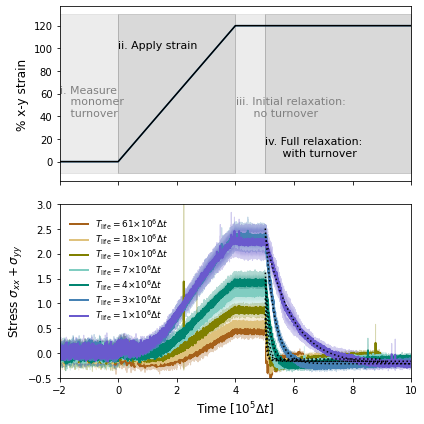

In [ ]:
# ---------------- Example usage ----------------
# You already have figNICE, axNICE = plt.subplots(2,1,...)
# and MPs, clrs, datadir0 defined.
#MPs = "0.01 0.03 0.06 0.09 0.18 0.27 0.6 0.81".split() # 0.03 0.06 0.09 0.18 0.27 0.6 0.81
MPs = "0.6 0.27 0.18 0.09 0.06 0.03 0.01 ".split() # 0.18 0.27 0.6 0.81 0.09 0.18 0.27 0.6 0.81 
#MonPref = "9 9 6 6 8 7 11 14".split() # 13 17 26 31   8 6 6 9 9
figNICE,axNICE=plt.subplots(2,1,figsize = (6,6))
outdir = Path(datadir0) / "Data"
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
# Optional: if you want the same legend labels you used before
# (requires you already have TLifeDenseControl defined in scope)
def my_label_fn(x):
    return (r'$T_{\mathrm{life}} = $'
            + str(np.round(np.divide(TLifeDenseControl[x], 1e6)).astype(int))
            + r'$\times10^6\Delta t$')


taus = plot_stress_from_files_with_fit(
    MPs=MPs,
    clrs=clrs,
    outdir=outdir,
    ax=axNICE[1],
    time_scale=1e5,
    fit_t_start=5.02e5,
    fit_t_end=5.02e5+5e5,
    label_fn=my_label_fn,     # or None
    annotate_tau=False        # set True if you want τ printed on the plot
)
text1 = 'Equilibrate'
text2 = 'i. Measure\n   monomer\n   turnover'
text3 = 'ii. Apply strain'
text4 = 'iii. Initial relaxation: \n     no turnover'
text5 = 'Add monomers'
text6 = 'iv. Full relaxation: \n     with turnover'


Times = [-3,0,4,6,10]
Strains = [0,0,120,120,120]
axNICE[0].plot(Times,Strains)
t_Eq,t_MT,t_strain,t_InitRel,t_FullRel = -3, 0, 4, 5, 10

axNICE[0].plot(Times,Strains,linestyle = '-',color = 'black')
axNICE[0].fill_between([-5,t_Eq],[-10,-10],[130,130],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_Eq,t_MT],[-10,-10],[130,130],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_MT,t_strain],[-10,-10],[130,130],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_strain,t_InitRel],[-10,-10],[130,130],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_InitRel,t_FullRel],[-10,-10],[130,130],alpha = 0.15,color = 'black')

axNICE[0].text(t_Eq+1.,40,text2,color = 'grey',fontsize = 11)
axNICE[0].text(t_MT+0.01,100,text3,color = 'black',fontsize = 11)
axNICE[0].text(t_strain+0.01,40,text4,color = 'grey',fontsize = 11)
axNICE[0].text(t_InitRel+0.02,5,text6,color = 'black',fontsize = 11)

axNICE[0].set_ylabel("% x-y strain",fontsize =12)
axNICE[1].set_ylabel("Stress $\sigma_{xx}+\sigma_{yy}$",fontsize = 12)
axNICE[1].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[0].set_xticklabels([])
axNICE[1].legend(frameon=False,loc = [0.02,0.3],fontsize = 9,labelspacing=0.12)
axNICE[1].set_xlim([-2,10])
axNICE[0].set_xlim([-2,10])
axNICE[1].set_ylim([-0.5,3])
figNICE.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[ 3443.06650729  4768.29772279  6640.75435437  9617.67637145
 15687.20224171 30642.58077272 91028.7048401 ]


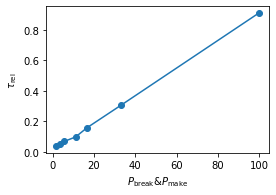

In [74]:
print(taus)
MPsV = [0.6,0.27,0.18,0.09,0.06,0.03,0.01]
fig,ax = plt.subplots(1,figsize = (4.,2.7))
ax.plot(np.divide(1,MPsV),np.divide(taus,1e5),marker = 'o')
#for i in range(3):
#    ax.plot(np.divide(1,MPsV),np.divide(Taus[:,i],1e5),marker = 'o',label = "seed"+str(i))
ax.set_xlabel(r"$P_{\mathrm{break}} & P_{\mathrm{make}}$")
ax.set_ylabel(r"$\tau_{\mathrm{rel}}$")
ax.legend(frameon=False)



MP=0.01: fit -> A=2.57, tau=9.1e+04, C=-0.22
MP=0.03: fit -> A=2.71, tau=3.06e+04, C=-0.208
MP=0.09: fit -> A=1.64, tau=9.62e+03, C=-0.161


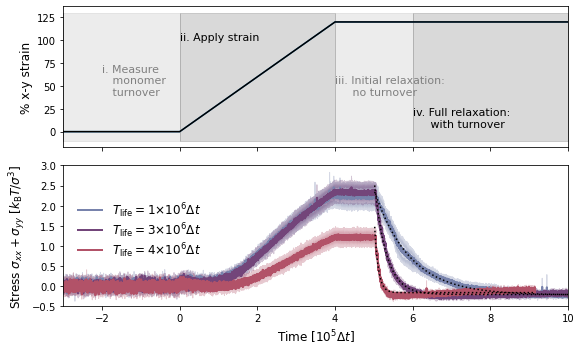

In [86]:
# ---------------- Example usage ----------------
# You already have figNICE, axNICE = plt.subplots(2,1,...)
# and MPs, clrs, datadir0 defined.
MPs = "0.01 0.03 0.09".split() # 0.03 0.06 0.09 0.18 0.27 0.6 0.81
figNICE,axNICE=plt.subplots(2,1,figsize = (8,5))
outdir = Path(datadir0) / "Data"
clrs = ClrsRiciChosenHalf
# Optional: if you want the same legend labels you used before
# (requires you already have TLifeDenseControl defined in scope)
def my_label_fn(x):
    return (r'$T_{\mathrm{life}} = $'
            + str(np.round(np.divide(TLifeDenseControl[x], 1e6)).astype(int))
            + r'$\times10^6\Delta t$')


taus2 = plot_stress_from_files_with_fit(
    MPs=MPs,
    clrs=clrs,
    outdir=outdir,
    ax=axNICE[1],
    time_scale=1e5,
    fit_t_start=5.02e5,
    fit_t_end=1.101e5 + 5.02e5+5e5,
    label_fn=my_label_fn,     # or None
    annotate_tau=False        # set True if you want τ printed on the plot
)
text1 = 'Equilibrate'
text2 = 'i. Measure\n   monomer\n   turnover'
text3 = 'ii. Apply strain'
text4 = 'iii. Initial relaxation: \n     no turnover'
text5 = 'Add monomers'
text6 = 'iv. Full relaxation: \n     with turnover'


Times = [-3,0,4,6,10]
Strains = [0,0,120,120,120]
axNICE[0].plot(Times,Strains)
t_Eq,t_MT,t_strain,t_InitRel,t_FullRel = -3, 0, 4, 6, 10

axNICE[0].plot(Times,Strains,linestyle = '-',color = 'black')
axNICE[0].fill_between([-5,t_Eq],[-10,-10],[130,130],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_Eq,t_MT],[-10,-10],[130,130],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_MT,t_strain],[-10,-10],[130,130],alpha = 0.15,color = 'black')
axNICE[0].fill_between([t_strain,t_InitRel],[-10,-10],[130,130],alpha = 0.15,color = 'grey')
axNICE[0].fill_between([t_InitRel,t_FullRel],[-10,-10],[130,130],alpha = 0.15,color = 'black')

axNICE[0].text(t_Eq+1.,40,text2,color = 'grey',fontsize = 11)
axNICE[0].text(t_MT+0.01,100,text3,color = 'black',fontsize = 11)
axNICE[0].text(t_strain+0.01,40,text4,color = 'grey',fontsize = 11)
axNICE[0].text(t_InitRel+0.02,5,text6,color = 'black',fontsize = 11)

axNICE[0].set_ylabel("% x-y strain",fontsize =12)
axNICE[1].set_ylabel(r"Stress $\sigma_{xx}+\sigma_{yy}~ [k_{\mathrm{B}}T/\sigma^3]$",fontsize = 12)
axNICE[1].set_xlabel("Time [$10^5\Delta t$]",fontsize = 12)
axNICE[0].set_xticklabels([])
axNICE[1].legend(frameon=False,loc = [0.02,0.3],fontsize = 12,labelspacing=0.12)
axNICE[1].set_xlim([-3,10])
axNICE[0].set_xlim([-3,10])
axNICE[1].set_ylim([-0.5,3])

figNICE.tight_layout()
figNICE.savefig(plotsdir + 'Stress_FromData.png',dpi = 300)


In [87]:
#TLifeDenseControl_ =[60659784.20757983,17744419.7023999, 9608369.203749232, 6929487.412154817, 4068293.605479009, 2799189.5261354707, 1432985.6901671062, 1241391.1983734763]
#TLifeDenseControlSTD_ =[3577912.0566655914,114349.62553078415, 138054.31284285168, 301665.7186546016, 122813.13094468458, 66358.84317330043, 39384.50459884934, 17725.03270429943]
TLifeDenseControl = [1432985.6901671062,2799189.5261354707,4068293.605479009,6929487.412154817,9608369.203749232,17744419.7023999,60659784.20757983]
TLifeDenseControlSTD  = [39384.50459884934,66358.84317330043,122813.13094468458,301665.7186546016,138054.31284285168,114349.62553078415,3577912.0566655914]
Taus_Std = [111.88367031,270.31056655 ,252.95813671,   731.79453038 , 2166.83233744 , 1499.83686007 , 5753.28351424]
Taus_Av = taus

#from : Scratch/Collagen/RiccyProject/Revision2/Stretch-AddDenseControl/Plotting/PlottingStress_CLEAN.ipynb


[ 3443.06650729  4768.29772279  6640.75435437  9617.67637145
 15687.20224171 30642.58077272 91028.7048401 ]
[ 3443.06650729  4768.29772279  6640.75435437  9617.67637145
 15687.20224171 30642.58077272 91028.7048401 ]


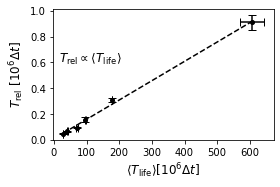

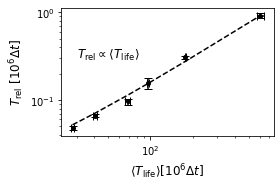

In [90]:
fig,ax = plt.subplots(1,figsize = (4.,2.7))
print(taus)
x1,y1 = np.array(np.divide(TLifeDenseControl[1:],10**5)),np.array(np.divide(Taus_Av[1:],10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
ax.errorbar(np.divide(TLifeDenseControl[1:],10**5),np.divide(Taus_Av[1:],10**5),yerr = np.divide(Taus_Std[1:],10**5), xerr = np.divide(TLifeDenseControlSTD[1:],10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
ax.text(15,0.6,text,color = 'black',fontsize = 12)
#---- log-log axis---#
#ax.set_xscale('log')
#ax.set_yscale('log')
#ax.set_xticks([0,200,400,600],['0','200','400','600'])
#ax.set_yticks([0,0.2,0.4,0.6,0.8],['0','0.2','0.4','0.6','0.8'])

fig.tight_layout()
fig.savefig(plotsdir + 'MasterTlifeTrelax.png',dpi = 300)

fig,ax = plt.subplots(1,figsize = (4.,2.7))
print(taus)
x1,y1 = np.array(np.divide(TLifeDenseControl[1:],10**5)),np.array(np.divide(Taus_Av[1:],10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
ax.errorbar(np.divide(TLifeDenseControl[1:],10**5),np.divide(Taus_Av[1:],10**5),yerr = np.divide(Taus_Std[1:],10**5), xerr = np.divide(TLifeDenseControlSTD[1:],10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
ax.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
ax.text(30,0.3,text,color = 'black',fontsize = 12)
#---- log-log axis---#
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xticks([0,200,400,600],['0','200','400','600'])
#ax.set_yticks([0,0.2,0.4,0.6,0.8],['0','0.2','0.4','0.6','0.8'])

fig.tight_layout()
fig.savefig(plotsdir + 'MasterTlifeTrelax_log.png',dpi = 300)
